# Advertising Sales Prediction

In this project, we analyze how different advertising channels such as TV, Radio, and Newspaper influence product sales.

We will build a Linear Regression model to:
- Analyze the relationship between advertising spending and sales.
- Predict sales for unseen data.
- Predict sales for a given advertising budget.
- Evaluate model performance.
- Interpret the model coefficients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the Dataset

The Advertising dataset contains information about advertising expenditure on different media and the corresponding product sales.

In [2]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Understanding the Dataset

First, we examine the available columns, number of rows, data types, and basic statistics.

In [3]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)
df.info()
df.describe()

Shape of dataset: (200, 4)

Columns:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

Data types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Checking Missing Values

Before building the model, we check whether the dataset contains any missing values.

In [4]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Feature Selection

The input features are:
- TV advertising spend
- Radio advertising spend
- Newspaper advertising spend

The target variable is Sales.

In [5]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Input features:")
print(X.head())

print("\nTarget variable:")
print(y.head())

Input features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target variable:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


## Train-Test Split

We divide the historical data into:
- 80% training data
- 20% testing data

The model learns from the training data and is evaluated using unseen testing data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


## Building the Model

We use Multiple Linear Regression because sales may be influenced by multiple advertising channels at the same time.

The model learns the relationship:

Sales = Intercept + TV coefficient + Radio coefficient + Newspaper coefficient

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## Model Coefficients

The coefficients tell us how much the predicted sales change when the spending on one advertising medium increases by one unit, while the other advertising spends remain constant.

In [8]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: 4.714126402214127

Coefficients:
TV: 0.0545
Radio: 0.1009
Newspaper: 0.0043


## Prediction on Test Data

Now we use the trained model to predict sales for the unseen testing data.

In [9]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


## Model Evaluation

We evaluate the prediction error using:

- MAE: Average absolute prediction error.
- MSE: Average squared prediction error.
- RMSE: Square root of MSE.
- R² Score: Measures how well the model explains the variation in sales.

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.2748262109549338
Mean Squared Error (MSE): 2.9077569102710896
Root Mean Squared Error (RMSE): 1.7052146229349223
R² Score: 0.9059011844150826


## Sales Prediction for a Planned Advertising Budget

The company plans to spend:

- TV = 150
- Radio = 20
- Newspaper = 30

We use the trained model to predict the expected sales.

In [11]:
new_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [20],
    "Newspaper": [30]
})

predicted_sales = model.predict(new_budget)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 15.039523680317231


## Coefficient Interpretation

We compare the regression coefficients of TV, Radio, and Newspaper.

A larger positive coefficient indicates a stronger estimated effect on sales, assuming the other advertising channels remain constant.

In [12]:
coefficients = pd.Series(model.coef_, index=X.columns)

print(coefficients)

strongest_medium = coefficients.idxmax()
least_medium = coefficients.idxmin()

print("\nStrongest impact:", strongest_medium)
print("Least impact:", least_medium)

TV           0.054509
Radio        0.100945
Newspaper    0.004337
dtype: float64

Strongest impact: Radio
Least impact: Newspaper


## Actual Sales vs Predicted Sales

This visualization compares the actual sales values with the sales predicted by the model.

If the model performs well, the points should be close to the diagonal line.

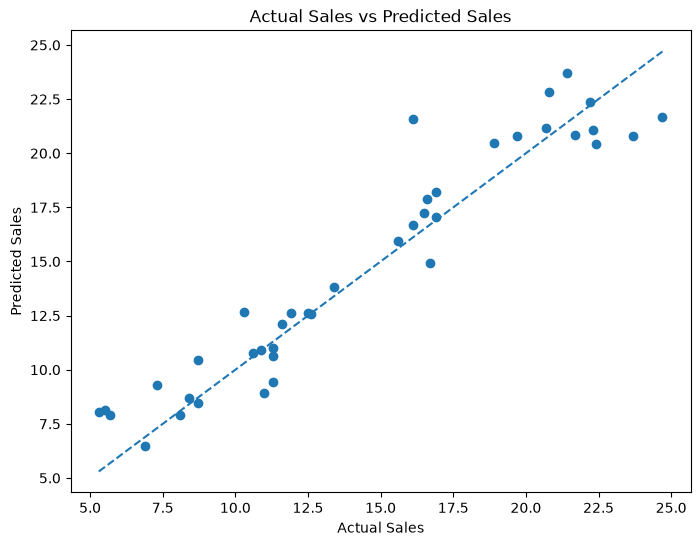

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## Advertising Medium Coefficients

The following chart helps us compare the estimated impact of each advertising channel.

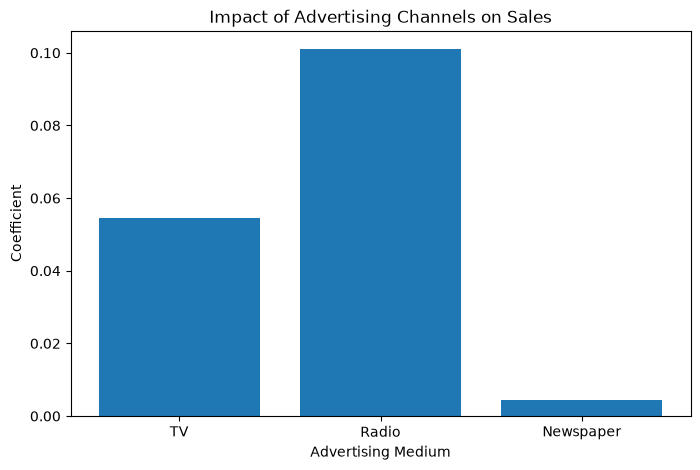

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(coefficients.index, coefficients.values)

plt.xlabel("Advertising Medium")
plt.ylabel("Coefficient")
plt.title("Impact of Advertising Channels on Sales")

plt.show()

## Business Recommendation

Based on the model coefficients, the company should focus more on the advertising medium that has the strongest positive impact on sales.

The company can prioritize Radio advertising while continuously monitoring the return on advertising investment.

Newspaper advertising has the weakest estimated impact, so the company can consider reducing or optimizing its newspaper advertising budget and reallocating part of it to more effective channels.

## Technical Improvement

The prediction accuracy can be improved by trying other regression models such as Random Forest Regression or Gradient Boosting.

We can also use cross-validation and hyperparameter tuning to select the best-performing model.

# Conclusion

The Multiple Linear Regression model was used to understand the relationship between TV, Radio, Newspaper advertising expenditure and Sales.

The model was trained using historical advertising data and tested on unseen data.

The model was also used to predict sales for a planned budget of:
- TV = 150
- Radio = 20
- Newspaper = 30

The regression coefficients helped identify which advertising medium has the strongest and weakest estimated impact on sales.

Business Recommendation:
Focus more on the advertising channel with the strongest positive impact and optimize spending on the weakest channel.

Technical Improvement:
Try advanced regression models, cross-validation, and hyperparameter tuning to improve prediction accuracy.